In [2]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,depths,reduce_list_half_preserve_extremes,my_languages

from geometry import * 

eps = 1E-7
rcpsize = 14
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.cm.tab10.colors  # 10 very distinct, saturated colors
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']


In [3]:
# modelA = 'deepseek'
# modelA = 'llama8b'
modelA = 'qwen7b'
modelB = modelA

layers_A = list(range(1,depths[modelA] + 1))
layers_B = list(range(1,depths[modelB] + 1))
layers = np.array(reduce_list_half_preserve_extremes(layers_A),dtype=float)
layers /= depths[modelB]

languages = [
            'english',
            # 'italian',
            # 'spanish',
            # 'german',
            # 'chinese',
            # 'arabic',
            # 'turkish',
            ]

batch_shuffle = 0
centers_var = 'sem'
min_token_length = 3
n_files = 21
n_tokens = min_token_length
avg_flags = [0]
match_var = 'matching'
data_var = 'sem'
Nbits = 0
language = 'english'


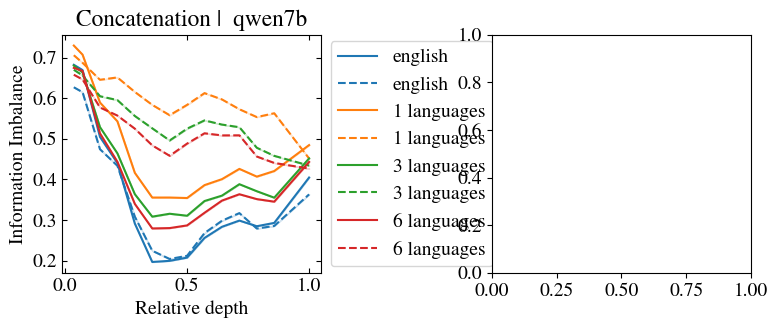

In [4]:
fig,ax = plt.subplots(1,2,figsize=(8,3.5))

plot_id = 0
def set_params(center_A_flag,
               center_B_flag,
               number_of_languages,
               language_list_permutation,
               removal_method,
               zero_activations,
               ):

  return  {'center_A_flag' : center_A_flag,
            'center_B_flag' : center_B_flag,
            'number_of_languages' : number_of_languages,
            'language_list_permutation' : language_list_permutation,
            'removal_method' : removal_method,
            'zero_activations' : zero_activations,
            }

params_list = [ ]

params_list.append(set_params(0,0,None,None,None,0))

for number_of_languages in [1,3,6]:
  params_list.append(set_params(1,0,number_of_languages,0,'subtraction',0))

# for number_of_languages in [1,3,6]:
#   params_list .append(set_params(1,0,number_of_languages,1,'subtraction',1))

for avg_id,avg_tokens in enumerate(avg_flags):
  plot_id = 0
  if avg_tokens:
    _n_tokens = -1
    _min_token_length = -1
  else:
    _n_tokens = n_tokens
    _min_token_length = min_token_length
  for params in params_list:
    title = ' '

    output_folder0 = makefolder(base=f'./results/',
                                global_centering=0,
                                spaces='AB',
                                similarity_fn='normalized_L2_distance',
                                precision=32,
                                language=language,
                                data_var=data_var,
                                modelA=modelA,
                                modelB=modelB,
                                match_var=match_var,
                                n_files=n_files,
                                min_token_length=_min_token_length,
                                )
    II_folder = makefolder(base=output_folder0,
                                      centers=centers_var,
                                      Nbits=Nbits,
                                      n_tokens=_n_tokens,
                                      avg_tokens=avg_tokens,
                                      batch_shuffle=batch_shuffle,
                                      zero_activations=params['zero_activations'],
                                      center_A_flag=params['center_A_flag'],
                                      center_B_flag=params['center_B_flag'],
                                      number_of_languages=params['number_of_languages'],
                                      language_list_permutation=params['language_list_permutation'],
                                      removal_method=params['removal_method'],
                                      )
    inf_imb = np.load(II_folder + "II.npy")
    std = np.load(II_folder + "II_jack_std.npy")
    color = colors[plot_id] 
    
    if avg_tokens:
      title = f'Average | '
    else:
      title = f'Concatenation | '

    label = ''
    if params['center_A_flag'] == 0:
      label += f'{language}'
    else:
      label += f'{params["number_of_languages"]} languages'

    for II_index in range(2):
      ax[avg_id].plot(layers,
              inf_imb[II_index].diagonal(),
              label=label,
              linestyle=_linestyles[II_index],
              color=color,
              ) 
      ax[avg_id].fill_between(layers,
                      inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                      inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                      alpha=0.2,
                      color=color,
                      )
    plot_id += 1

    ax[avg_id].set_xlabel('Relative depth')
    if avg_id == 0:
      ax[avg_id].set_ylabel('Information Imbalance')
    ax[avg_id].set_title(title + f' {modelA}')

    ax[avg_id].grid()
    ax[avg_id].tick_params(
        top=True, bottom=True, left=True, right=True,  # enable ticks
        labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
        direction='in'  # ticks point inward
        )
  # ax[avg_id].set_ylim(0.05,.85)
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/semantic_similarity_{modelA}.pdf', bbox_inches='tight')
plt.show()

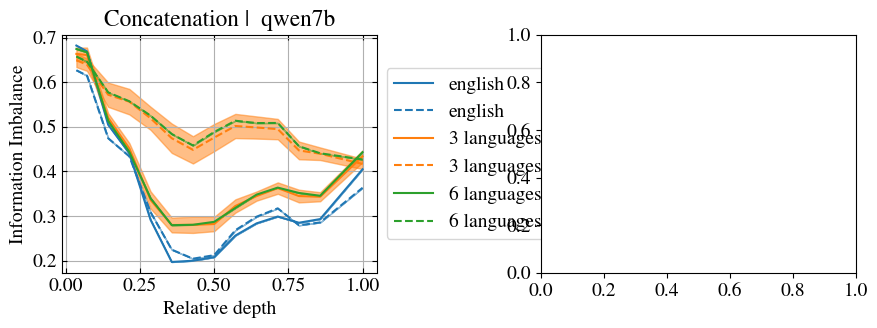

In [9]:
fig,ax = plt.subplots(1,2,figsize=(9,3.5))

def set_params(center_A_flag,
               center_B_flag,
               number_of_languages,
               language_list_permutation,
               removal_method,
               zero_activations,
               ):

  return  {'center_A_flag' : center_A_flag,
            'center_B_flag' : center_B_flag,
            'number_of_languages' : number_of_languages,
            'language_list_permutation' : language_list_permutation,
            'removal_method' : removal_method,
            'zero_activations' : zero_activations,
            }



language_list_permutations = [0,1,2,3,4,5] 


for avg_id,avg_tokens in enumerate(avg_flags):
  plot_id = 0
  if avg_tokens:
    title = f'Average | '
    _n_tokens = -1
    _min_token_length = -1
  else:
    title = f'Concatenation | '
    _n_tokens = n_tokens
    _min_token_length = min_token_length
  
    # params_list.append(set_params(0,0,None,None,None,0)) # baseline
    for number_of_languages in [None,3,6]:
      inf_imb = np.zeros(shape=(len(language_list_permutations),2,len(layers)))
      for permutation_id, language_list_permutation in enumerate(language_list_permutations):
        
        if number_of_languages is None:
          params = set_params(0,0,number_of_languages,None,None,0)
        else:
          # params = set_params(1,1,number_of_languages,language_list_permutation,'subtraction',0)
          params = set_params(1,0,number_of_languages,language_list_permutation,'subtraction',0)
        output_folder0 = makefolder(base=f'./results/',
                                    global_centering=0,
                                    spaces='AB',
                                    similarity_fn='normalized_L2_distance',
                                    precision=32,
                                    language=language,
                                    data_var=data_var,
                                    modelA=modelA,
                                    modelB=modelB,
                                    match_var=match_var,
                                    n_files=n_files,
                                    min_token_length=_min_token_length,
                                    )
        II_folder = makefolder(base=output_folder0,
                                          centers=centers_var,
                                          Nbits=Nbits,
                                          n_tokens=_n_tokens,
                                          avg_tokens=avg_tokens,
                                          batch_shuffle=batch_shuffle,
                                          zero_activations=params['zero_activations'],
                                          center_A_flag=params['center_A_flag'],
                                          center_B_flag=params['center_B_flag'],
                                          number_of_languages=params['number_of_languages'],
                                          language_list_permutation=params['language_list_permutation'],
                                          removal_method=params['removal_method'],
                                          )

        inf_imb[permutation_id,:,:] = np.diagonal(np.load(II_folder + "II.npy"),axis1=1,axis2=2)
        # std = np.load(II_folder + "II_jack_std.npy").diagonal()
        color = colors[plot_id] 

        label = ''
        if params['center_A_flag'] == 0:
          label += f'{language}'
        else:
          label += f'{params["number_of_languages"]} languages'

      for II_index in range(2):
        if number_of_languages == None: baseline = inf_imb[:,II_index,:].mean(axis=0)
        ax[avg_id].plot(layers,
                inf_imb[:,II_index,:].mean(axis=0),
                label=label,
                linestyle=_linestyles[II_index],
                color=color,
                ) 
        ax[avg_id].fill_between(layers,
                        inf_imb[:,II_index,:].mean(axis=0) - inf_imb[:,II_index,:].std(axis=0),
                        inf_imb[:,II_index,:].mean(axis=0) + inf_imb[:,II_index,:].std(axis=0),
                        alpha=0.5,
                        color=color,
                        )
      plot_id += 1

      # if number_of_languages == 6:
      #   ax[avg_id].plot(layers,
      #                   inf_imb[:,II_index,:].mean(axis=0)-baseline,
      #                   color='black',
      #                   label='max_difference',
      #                   )

  ax[avg_id].set_xlabel('Relative depth')
  if avg_id == 0:
    ax[avg_id].set_ylabel('Information Imbalance')
  ax[avg_id].set_title(title + f' {modelA}')

  ax[avg_id].grid()
  ax[avg_id].tick_params(
      top=True, bottom=True, left=True, right=True,  # enable ticks
      labeltop=False, labelbottom=True, labelleft=True, labelright=False, # enable labels if needed
      direction='in'  # ticks point inward
      )
  # ax[avg_id].set_ylim(0.05,.85)
box = ax[0].get_position()
ax[0].set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
os.makedirs('results/figs', exist_ok=True)
# fig.savefig(f'results/figs/semantic_similarity_{modelA}.pdf', bbox_inches='tight')
plt.show()